<a href="https://colab.research.google.com/github/juand-sketch/Trabajos-phyton/blob/main/Taller_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Felicidades, has terminado el Curso de Introducción a Python**

Para ello vamos a hacer un pequeño desafio que nos permita poner en practica todo lo que hemos aprendido a lo largo de este curso.


Empecemos creando nuestra base de datos usando Yahoo Finance

1. descarga 6 activos difrentes con los valores del ultimo año (entre ellos elige una criptomoneda y el dolar en pesos (COP=X), con una periodicidad díaria, y elije el valor del cierre (Close) y el volumen (Volume) de los movimientos, verifica los datos y limpia si es necesario con la estrategia de valores vecinos.

2. Crea una nueva variable categorica llamada "catvolume#NombreActivo", en función de uno de los activos y sus valores de volumen de venta, en donde dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio" al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

3. Crea una columna adicional que se llame index y ponla en la primera columna de datos

4. Crea una columna de la criptomoneda en valores pesos multiplicandola por el valor del dolar en cada día.

5. Crea un resumen estadistico de las variables y analizar

6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma,  diagrama de cajas y bigotes y diagrama circular (Variable categorica)

7. Realice una matriz de correlación para las variables originales

8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

In [4]:
#Importación y limpeza de datos
import yfinance as yf
tickers="CELSIA.CL", "NUTRESA.CL", "BOGOTA.CL", "GEB.CL","BTC-USD", "COP=X"
data=yf.download(tickers=tickers,period="1y", interval="1d",
                 auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()


[*********************100%***********************]  6 of 6 completed
/tmp/ipython-input-441382918.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()


In [5]:
#Visualización de los datos
data.head()

Price              Close                                           \
Ticker         BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
Date                                                                
2024-12-04  25760.833984   96593.570312  3333.324707  4425.750000   
2024-12-05  25703.628906   96593.570312  3347.590088  4425.750000   
2024-12-06  26027.787109   99920.710938  3347.590088  4413.669922   
2024-12-07  25913.378906   99923.335938  3338.079834  4376.152344   
2024-12-08  25913.378906  101236.015625  3338.079834  4376.152344   

Price                                 Volume                                \
Ticker           GEB.CL NUTRESA.CL BOGOTA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                         
2024-12-04  2378.426270    79000.0    9416.0  1.492189e+11  466144.0   0.0   
2024-12-05  2378.426270    79000.0   21791.0  1.492189e+11  156726.0   0.0   
2024-12-06  2393.324707    79000.0     504.0  9.453477e+10  111610.0   0.0   
2024-12-07  2383.712891    79000.0   14767.0  4.417751e+10  160469.0   0.0   
2024-12-08  2383.712891    79000.0   14767.0  4.412575e+10  160469.0   0.0   

Price                            
Ticker        GEB.CL NUTRESA.CL  
Date                             
2024-12-04  188403.0       21.0  
2024-12-05  451597.0       34.0  
2024-12-06  663973.0     1395.0  
2024-12-07  690666.0       13.0  
2024-12-08  690666.0       13.0

In [6]:
len(data)

366

In [7]:
data.isnull().sum()

Price   Ticker    
Close   BOGOTA.CL     0
        BTC-USD       0
        CELSIA.CL     0
        COP=X         0
        GEB.CL        0
        NUTRESA.CL    0
Volume  BOGOTA.CL     0
        BTC-USD       0
        CELSIA.CL     0
        COP=X         0
        GEB.CL        0
        NUTRESA.CL    0
dtype: int64

In [8]:
##2. Crea una nueva variable categorica llamada "catvolume#NombreActivo",
#en función de uno de los activos y sus valores de volumen de venta, en donde
#dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio"
#al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

import pandas as pd
#Crear la nueva variable

volume_Nutresa = data['Volume']['GEB.CL']

# Calcular cuartiles y crear la columna
labels = ['bajo', 'medio', 'alto', 'muy_alto']
data['Volume', 'catvolumeGEB.CL'] = pd.qcut(volume_Nutresa, q=4, labels=labels, duplicates='drop')


In [9]:
#Validar nueva columna Catvolumexxxx
data

Price              Close                                           \
Ticker         BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
Date                                                                
2024-12-04  25760.833984   96593.570312  3333.324707  4425.750000   
2024-12-05  25703.628906   96593.570312  3347.590088  4425.750000   
2024-12-06  26027.787109   99920.710938  3347.590088  4413.669922   
2024-12-07  25913.378906   99923.335938  3338.079834  4376.152344   
2024-12-08  25913.378906  101236.015625  3338.079834  4376.152344   
...                  ...            ...          ...          ...   
2025-11-30  38500.000000   90394.312500  4900.000000  3691.856689   
2025-12-01  38500.000000   86321.570312  4900.000000  3691.856689   
2025-12-02  38500.000000   91350.203125  4905.000000  3808.399902   
2025-12-03  38340.000000   93527.804688  4865.000000  3816.250000   
2025-12-04  38200.000000   92320.882812  4950.000000  3768.149902   

Price                                 Volume                                \
Ticker           GEB.CL NUTRESA.CL BOGOTA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                         
2024-12-04  2378.426270    79000.0    9416.0  1.492189e+11  466144.0   0.0   
2024-12-05  2378.426270    79000.0   21791.0  1.492189e+11  156726.0   0.0   
2024-12-06  2393.324707    79000.0     504.0  9.453477e+10  111610.0   0.0   
2024-12-07  2383.712891    79000.0   14767.0  4.417751e+10  160469.0   0.0   
2024-12-08  2383.712891    79000.0   14767.0  4.412575e+10  160469.0   0.0   
...                 ...        ...       ...           ...       ...   ...   
2025-11-30  3210.000000   262980.0    7265.0  3.849790e+10  131675.0   0.0   
2025-12-01  3210.000000   262980.0    7265.0  8.796289e+10  131675.0   0.0   
2025-12-02  3200.000000   262800.0    3095.0  7.854680e+10  187359.0   0.0   
2025-12-03  3145.000000   272960.0    4600.0  7.765020e+10   42165.0   0.0   
2025-12-04  3200.000000   256800.0    5702.0  6.178999e+10  221392.0   0.0   

Price                                             
Ticker         GEB.CL NUTRESA.CL catvolumeGEB.CL  
Date                                              
2024-12-04   188403.0       21.0            bajo  
2024-12-05   451597.0       34.0           medio  
2024-12-06   663973.0     1395.0            alto  
2024-12-07   690666.0       13.0            alto  
2024-12-08   690666.0       13.0            alto  
...               ...        ...             ...  
2025-11-30  1141876.0     1905.0        muy_alto  
2025-12-01  1141876.0     1905.0        muy_alto  
2025-12-02  1915142.0      986.0        muy_alto  
2025-12-03   198968.0      557.0            bajo  
2025-12-04  1020896.0      333.0        muy_alto  

[366 rows x 13 columns]

In [10]:
#Contar cantidad de valores por categoria
print(data['Volume', 'catvolumeGEB.CL'].value_counts())

(Volume, catvolumeGEB.CL)
bajo        94
alto        92
muy_alto    91
medio       89
Name: count, dtype: int64


In [11]:
## NUeva Columna llamada Index
Index = range(1, len(data) + 1)

print(Index)

data.insert(0, 'Index', Index)

range(1, 367)


In [12]:
data

Price      Index         Close                                           \
Ticker               BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
Date                                                                      
2024-12-04     1  25760.833984   96593.570312  3333.324707  4425.750000   
2024-12-05     2  25703.628906   96593.570312  3347.590088  4425.750000   
2024-12-06     3  26027.787109   99920.710938  3347.590088  4413.669922   
2024-12-07     4  25913.378906   99923.335938  3338.079834  4376.152344   
2024-12-08     5  25913.378906  101236.015625  3338.079834  4376.152344   
...          ...           ...            ...          ...          ...   
2025-11-30   362  38500.000000   90394.312500  4900.000000  3691.856689   
2025-12-01   363  38500.000000   86321.570312  4900.000000  3691.856689   
2025-12-02   364  38500.000000   91350.203125  4905.000000  3808.399902   
2025-12-03   365  38340.000000   93527.804688  4865.000000  3816.250000   
2025-12-04   366  38200.000000   92320.882812  4950.000000  3768.149902   

Price                                 Volume                                \
Ticker           GEB.CL NUTRESA.CL BOGOTA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                         
2024-12-04  2378.426270    79000.0    9416.0  1.492189e+11  466144.0   0.0   
2024-12-05  2378.426270    79000.0   21791.0  1.492189e+11  156726.0   0.0   
2024-12-06  2393.324707    79000.0     504.0  9.453477e+10  111610.0   0.0   
2024-12-07  2383.712891    79000.0   14767.0  4.417751e+10  160469.0   0.0   
2024-12-08  2383.712891    79000.0   14767.0  4.412575e+10  160469.0   0.0   
...                 ...        ...       ...           ...       ...   ...   
2025-11-30  3210.000000   262980.0    7265.0  3.849790e+10  131675.0   0.0   
2025-12-01  3210.000000   262980.0    7265.0  8.796289e+10  131675.0   0.0   
2025-12-02  3200.000000   262800.0    3095.0  7.854680e+10  187359.0   0.0   
2025-12-03  3145.000000   272960.0    4600.0  7.765020e+10   42165.0   0.0   
2025-12-04  3200.000000   256800.0    5702.0  6.178999e+10  221392.0   0.0   

Price                                             
Ticker         GEB.CL NUTRESA.CL catvolumeGEB.CL  
Date                                              
2024-12-04   188403.0       21.0            bajo  
2024-12-05   451597.0       34.0           medio  
2024-12-06   663973.0     1395.0            alto  
2024-12-07   690666.0       13.0            alto  
2024-12-08   690666.0       13.0            alto  
...               ...        ...             ...  
2025-11-30  1141876.0     1905.0        muy_alto  
2025-12-01  1141876.0     1905.0        muy_alto  
2025-12-02  1915142.0      986.0        muy_alto  
2025-12-03   198968.0      557.0            bajo  
2025-12-04  1020896.0      333.0        muy_alto  

[366 rows x 14 columns]

In [13]:
##Crea una columna de la criptomoneda en valores pesos multiplicandola por el
#valor del dolar en cada día.

BTCCOP = data['Close', 'BTC-USD'] * data['Close', 'COP=X']

data.insert(14,"BTC-COP",BTCCOP)

In [14]:
data

Price      Index         Close                                           \
Ticker               BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
Date                                                                      
2024-12-04     1  25760.833984   96593.570312  3333.324707  4425.750000   
2024-12-05     2  25703.628906   96593.570312  3347.590088  4425.750000   
2024-12-06     3  26027.787109   99920.710938  3347.590088  4413.669922   
2024-12-07     4  25913.378906   99923.335938  3338.079834  4376.152344   
2024-12-08     5  25913.378906  101236.015625  3338.079834  4376.152344   
...          ...           ...            ...          ...          ...   
2025-11-30   362  38500.000000   90394.312500  4900.000000  3691.856689   
2025-12-01   363  38500.000000   86321.570312  4900.000000  3691.856689   
2025-12-02   364  38500.000000   91350.203125  4905.000000  3808.399902   
2025-12-03   365  38340.000000   93527.804688  4865.000000  3816.250000   
2025-12-04   366  38200.000000   92320.882812  4950.000000  3768.149902   

Price                                 Volume                                \
Ticker           GEB.CL NUTRESA.CL BOGOTA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                         
2024-12-04  2378.426270    79000.0    9416.0  1.492189e+11  466144.0   0.0   
2024-12-05  2378.426270    79000.0   21791.0  1.492189e+11  156726.0   0.0   
2024-12-06  2393.324707    79000.0     504.0  9.453477e+10  111610.0   0.0   
2024-12-07  2383.712891    79000.0   14767.0  4.417751e+10  160469.0   0.0   
2024-12-08  2383.712891    79000.0   14767.0  4.412575e+10  160469.0   0.0   
...                 ...        ...       ...           ...       ...   ...   
2025-11-30  3210.000000   262980.0    7265.0  3.849790e+10  131675.0   0.0   
2025-12-01  3210.000000   262980.0    7265.0  8.796289e+10  131675.0   0.0   
2025-12-02  3200.000000   262800.0    3095.0  7.854680e+10  187359.0   0.0   
2025-12-03  3145.000000   272960.0    4600.0  7.765020e+10   42165.0   0.0   
2025-12-04  3200.000000   256800.0    5702.0  6.178999e+10  221392.0   0.0   

Price                                                  BTC-COP  
Ticker         GEB.CL NUTRESA.CL catvolumeGEB.CL                
Date                                                            
2024-12-04   188403.0       21.0            bajo  4.274990e+08  
2024-12-05   451597.0       34.0           medio  4.274990e+08  
2024-12-06   663973.0     1395.0            alto  4.410170e+08  
2024-12-07   690666.0       13.0            alto  4.372797e+08  
2024-12-08   690666.0       13.0            alto  4.430242e+08  
...               ...        ...             ...           ...  
2025-11-30  1141876.0     1905.0        muy_alto  3.337228e+08  
2025-12-01  1141876.0     1905.0        muy_alto  3.186869e+08  
2025-12-02  1915142.0      986.0        muy_alto  3.478981e+08  
2025-12-03   198968.0      557.0            bajo  3.569255e+08  
2025-12-04  1020896.0      333.0        muy_alto  3.478789e+08  

[366 rows x 15 columns]

In [15]:
# 5. Crea un resumen estadistico de las variables y analizar

data.describe()

Price        Index         Close                                           \
Ticker                 BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
count   366.000000    366.000000     366.000000   366.000000   366.000000   
mean    183.500000  31356.689912  102349.724641  4216.914458  4083.737555   
std     105.799338   3684.236222   11239.043641   529.204940   178.830172   
min       1.000000  24845.572266   76271.953125  3304.793945  3691.856689   
25%      92.250000  28968.705078   94529.041016  3631.501709  3984.860107   
50%     183.500000  31340.037109  103723.925781  4342.657959  4092.250488   
75%     274.750000  34328.714844  110977.412109  4730.496582  4204.062500   
max     366.000000  38807.667969  124752.531250  5000.000000  4425.750000   

Price                                      Volume                              \
Ticker       GEB.CL     NUTRESA.CL      BOGOTA.CL       BTC-USD     CELSIA.CL   
count    366.000000     366.000000     366.000000  3.660000e+02  3.660000e+02   
mean    2798.519973  142287.486339   14814.338798  5.498002e+10  2.639057e+05   
std      227.654110   54242.846005   15854.103414  2.541732e+10  2.999626e+05   
min     2326.042480   71600.000000       0.000000  9.863214e+09  0.000000e+00   
25%     2682.878479  118000.000000    5186.750000  3.734962e+10  1.144118e+05   
50%     2852.285522  126600.000000   10546.000000  5.155519e+10  1.678045e+05   
75%     2945.000000  149770.000000   19364.000000  6.938983e+10  3.058180e+05   
max     3235.000000  296000.000000  169212.000000  1.817464e+11  2.037922e+06   

Price                                           BTC-COP  
Ticker  COP=X        GEB.CL    NUTRESA.CL                
count   366.0  3.660000e+02    366.000000  3.660000e+02  
mean      0.0  8.506834e+05   2464.161202  4.173194e+08  
std       0.0  1.208967e+06   8615.158614  4.310058e+07  
min       0.0  0.000000e+00      0.000000  3.146875e+08  
25%       0.0  2.575220e+05    171.000000  3.950441e+08  
50%       0.0  5.151510e+05    493.000000  4.289036e+08  
75%       0.0  9.920840e+05   1579.000000  4.460572e+08  
max       0.0  1.212056e+07  71434.000000  4.956890e+08

In [17]:
## 6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma, diagrama de cajas y bigotes y diagrama circular (Variable categorica)
close_data = data['Close']
close_data.head()

Ticker,BOGOTA.CL,BTC-USD,CELSIA.CL,COP=X,GEB.CL,NUTRESA.CL
Date,,,,,,
2024-12-04,25760.833984,96593.570312,3333.324707,4425.750000,2378.426270,79000.0
2024-12-05,25703.628906,96593.570312,3347.590088,4425.750000,2378.426270,79000.0
2024-12-06,26027.787109,99920.710938,3347.590088,4413.669922,2393.324707,79000.0
2024-12-07,25913.378906,99923.335938,3338.079834,4376.152344,2383.712891,79000.0
2024-12-08,25913.378906,101236.015625,3338.079834,4376.152344,2383.712891,79000.0


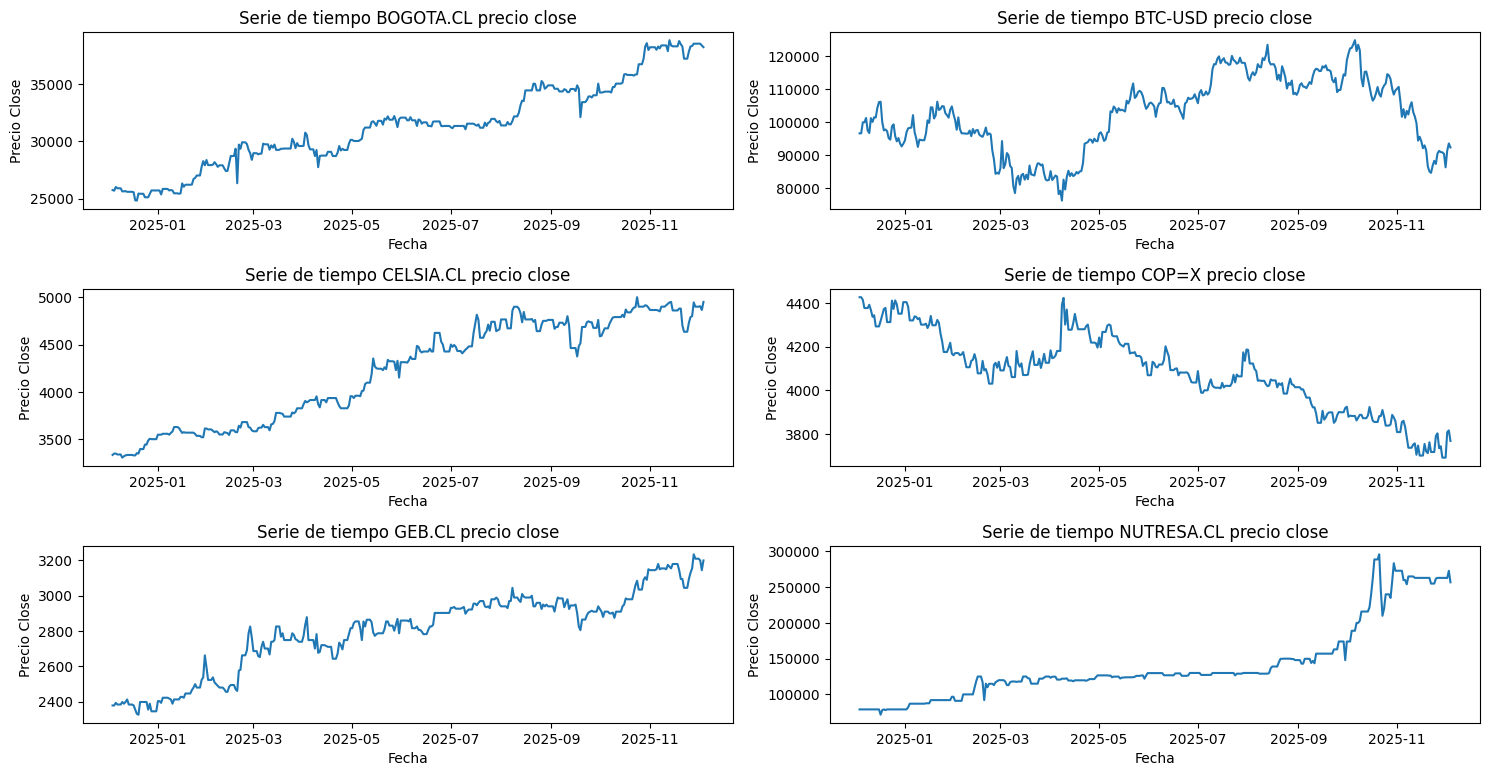

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.lineplot(x=close_data.index, y=close_data[column])
    plt.title(f'Serie de tiempo {column} precio close')
    plt.xlabel('Fecha')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

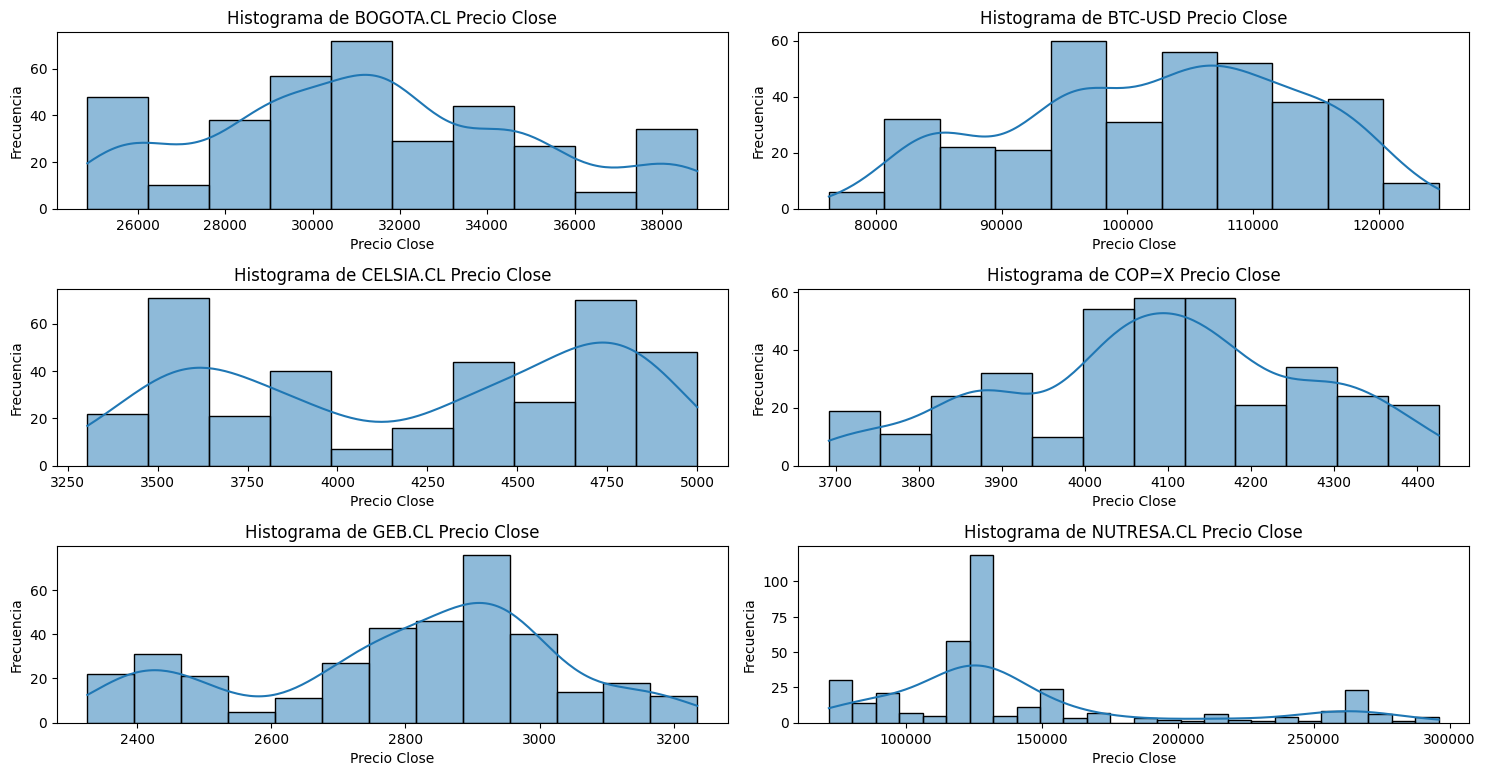

In [19]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.histplot(close_data[column], kde=True)
    plt.title(f'Histograma de {column} Precio Close')
    plt.xlabel('Precio Close')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

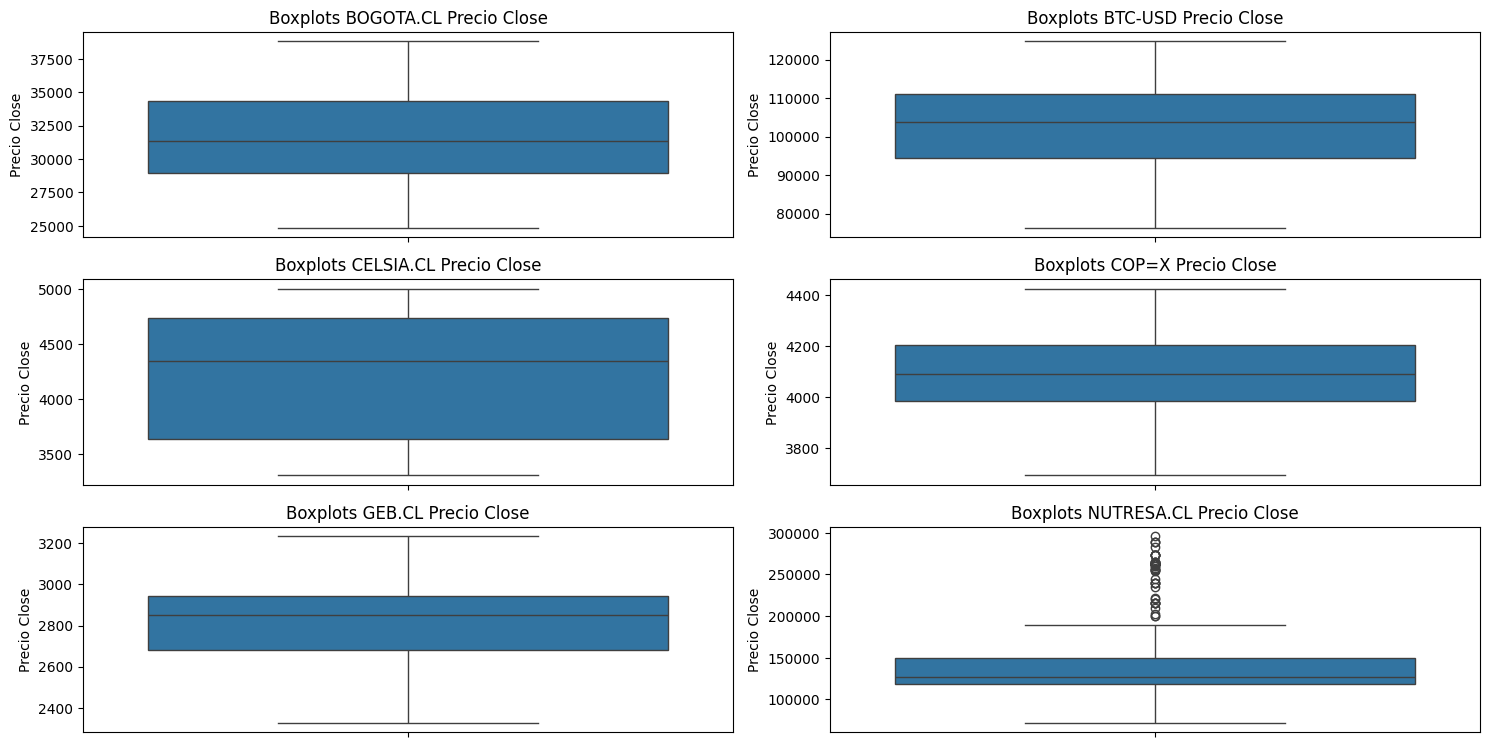

In [20]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.boxplot(y=close_data[column])
    plt.title(f'Boxplots {column} Precio Close')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

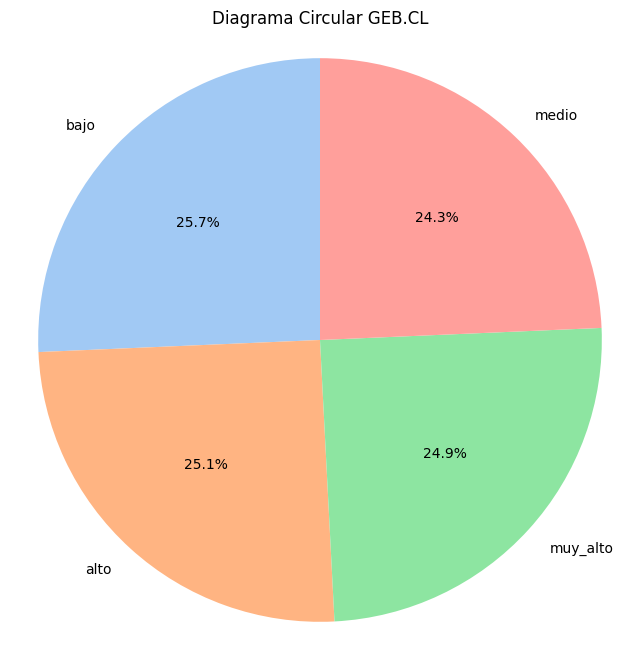

In [22]:
plt.figure(figsize=(8, 8))
volume_category_counts = data['Volume', 'catvolumeGEB.CL'].value_counts()
plt.pie(volume_category_counts, labels=volume_category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Diagrama Circular GEB.CL')
plt.axis('equal')
plt.show()

In [23]:
## 7. Matriz de correllación de las variables

corr_k = data.corr(method="kendall", numeric_only=True)

corr_k

Price                  Index     Close                                \
Ticker                       BOGOTA.CL   BTC-USD CELSIA.CL     COP=X   
Price   Ticker                                                         
Index               1.000000  0.826899  0.327811  0.856228 -0.726944   
Close   BOGOTA.CL   0.826899  1.000000  0.298408  0.775467 -0.689435   
        BTC-USD     0.327811  0.298408  1.000000  0.353905 -0.285539   
        CELSIA.CL   0.856228  0.775467  0.353905  1.000000 -0.627550   
        COP=X      -0.726944 -0.689435 -0.285539 -0.627550  1.000000   
        GEB.CL      0.803504  0.776081  0.329147  0.809291 -0.649269   
        NUTRESA.CL  0.888908  0.810412  0.317358  0.793707 -0.725940   
Volume  BOGOTA.CL  -0.025124 -0.001988 -0.063022 -0.029533 -0.042799   
        BTC-USD     0.211754  0.218416  0.244603  0.228281 -0.159679   
        CELSIA.CL  -0.107084 -0.074873 -0.171066 -0.128451  0.038335   
        COP=X            NaN       NaN       NaN       NaN       NaN   
        GEB.CL      0.009680  0.026765 -0.100556  0.013576 -0.059644   
        NUTRESA.CL -0.012311  0.030240 -0.230179 -0.027132 -0.026188   
BTC-COP             0.117345  0.100711  0.748211  0.173420 -0.033429   

Price                                      Volume                            \
Ticker                GEB.CL NUTRESA.CL BOGOTA.CL   BTC-USD CELSIA.CL COP=X   
Price   Ticker                                                                
Index               0.803504   0.888908 -0.025124  0.211754 -0.107084   NaN   
Close   BOGOTA.CL   0.776081   0.810412 -0.001988  0.218416 -0.074873   NaN   
        BTC-USD     0.329147   0.317358 -0.063022  0.244603 -0.171066   NaN   
        CELSIA.CL   0.809291   0.793707 -0.029533  0.228281 -0.128451   NaN   
        COP=X      -0.649269  -0.725940 -0.042799 -0.159679  0.038335   NaN   
        GEB.CL      1.000000   0.783149 -0.009816  0.208515 -0.106267   NaN   
        NUTRESA.CL  0.783149   1.000000 -0.021964  0.194453 -0.099413   NaN   
Volume  BOGOTA.CL  -0.009816  -0.021964  1.000000  0.036306  0.332032   NaN   
        BTC-USD     0.208515   0.194453  0.036306  1.000000 -0.072971   NaN   
        CELSIA.CL  -0.106267  -0.099413  0.332032 -0.072971  1.000000   NaN   
        COP=X            NaN        NaN       NaN       NaN       NaN   1.0   
        GEB.CL      0.057853   0.018162  0.365404  0.059493  0.328910   NaN   
        NUTRESA.CL -0.001239   0.001046  0.125062 -0.057158  0.228084   NaN   
BTC-COP             0.144674   0.102371 -0.079081  0.234632 -0.168154   NaN   

Price                                     BTC-COP  
Ticker                GEB.CL NUTRESA.CL            
Price   Ticker                                     
Index               0.009680  -0.012311  0.117345  
Close   BOGOTA.CL   0.026765   0.030240  0.100711  
        BTC-USD    -0.100556  -0.230179  0.748211  
        CELSIA.CL   0.013576  -0.027132  0.173420  
        COP=X      -0.059644  -0.026188 -0.033429  
        GEB.CL      0.057853  -0.001239  0.144674  
        NUTRESA.CL  0.018162   0.001046  0.102371  
Volume  BOGOTA.CL   0.365404   0.125062 -0.079081  
        BTC-USD     0.059493  -0.057158  0.234632  
        CELSIA.CL   0.328910   0.228084 -0.168154  
        COP=X            NaN        NaN       NaN  
        GEB.CL      1.000000   0.146868 -0.120518  
        NUTRESA.CL  0.146868   1.000000 -0.267924  
BTC-COP            -0.120518  -0.267924  1.000000

In [25]:
### 8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Calcular media móvil de 5 periodos
# Asigna la nueva columna usando un MultiIndex para que se integre correctamente
data[('Price', "NUTRESA.CLMA5")] = data['Close']["NUTRESA.CL"].rolling(window=5).mean().shift(1).fillna(data['Close']["NUTRESA.CL"].iloc[0:4].mean())

# Preparar datos (eliminar NaN de la nueva columna para el cálculo de métricas)
# Usa el nombre de la columna MultiIndex para subset
datos_ma5 = data.dropna(subset=[('Price', "NUTRESA.CLMA5")])

# Las 'predicciones' son ahora los valores de la media móvil
y_pred_ma = datos_ma5[('Price', "NUTRESA.CLMA5")].values

# Alinear los valores originales de 'MINEROS.CL' con la longitud de los datos de la media móvil
y_original_aligned = datos_ma5['Close']['NUTRESA.CL'].values

# Parámetros y métricas
# En este enfoque de media móvil directa, no hay 'pendiente' ni 'intercepto' de un modelo de regresión
# Sin embargo, aún podemos calcular R2 y RMSE comparando la MA con los datos originales

r2 = r2_score(y_original_aligned, y_pred_ma)
rmse = np.sqrt(mean_squared_error(y_original_aligned, y_pred_ma))

print("ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)")
print(f"El pronóstico es directamente la Media Móvil de 5 períodos.")
print(f"\nMÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Observaciones: {len(y_original_aligned)}")

ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)
El pronóstico es directamente la Media Móvil de 5 períodos.

MÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):
R²: 0.9731
RMSE: 8878.9567
Observaciones: 366


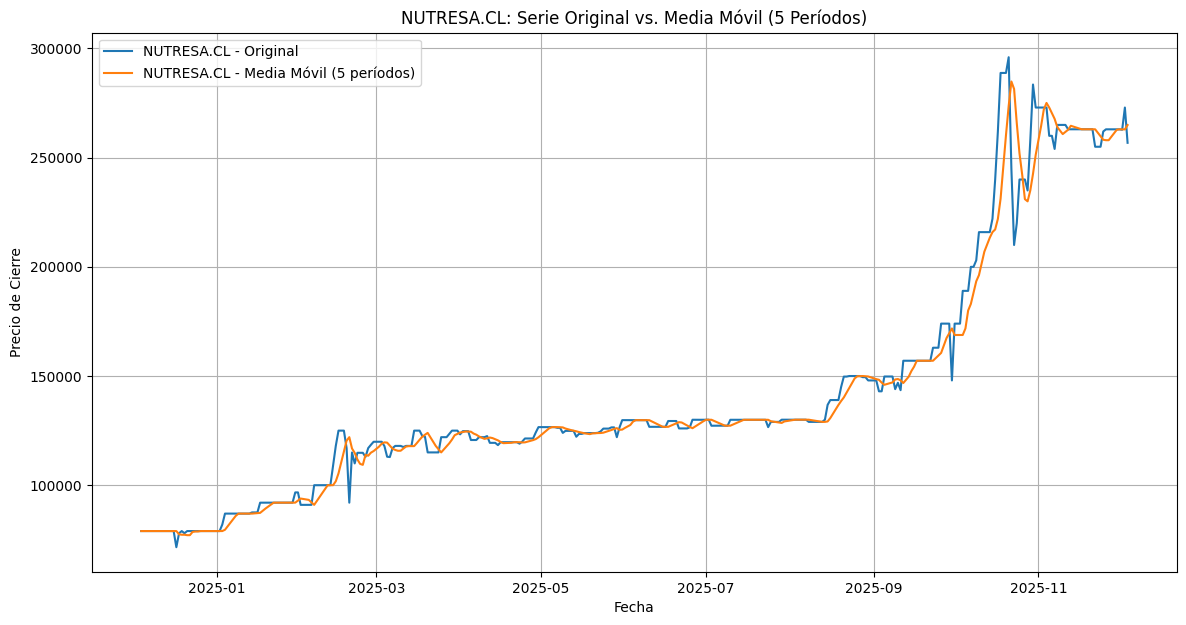

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=datos_ma5.index, y=datos_ma5['Close']['NUTRESA.CL'], label='NUTRESA.CL - Original')
sns.lineplot(x=datos_ma5.index, y=datos_ma5[('Price', 'NUTRESA.CLMA5')], label='NUTRESA.CL - Media Móvil (5 períodos)')
plt.title('NUTRESA.CL: Serie Original vs. Media Móvil (5 Períodos)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
data

Price      Index         Close                                           \
Ticker               BOGOTA.CL        BTC-USD    CELSIA.CL        COP=X   
Date                                                                      
2024-12-04     1  25760.833984   96593.570312  3333.324707  4425.750000   
2024-12-05     2  25703.628906   96593.570312  3347.590088  4425.750000   
2024-12-06     3  26027.787109   99920.710938  3347.590088  4413.669922   
2024-12-07     4  25913.378906   99923.335938  3338.079834  4376.152344   
2024-12-08     5  25913.378906  101236.015625  3338.079834  4376.152344   
...          ...           ...            ...          ...          ...   
2025-11-30   362  38500.000000   90394.312500  4900.000000  3691.856689   
2025-12-01   363  38500.000000   86321.570312  4900.000000  3691.856689   
2025-12-02   364  38500.000000   91350.203125  4905.000000  3808.399902   
2025-12-03   365  38340.000000   93527.804688  4865.000000  3816.250000   
2025-12-04   366  38200.000000   92320.882812  4950.000000  3768.149902   

Price                                 Volume                                \
Ticker           GEB.CL NUTRESA.CL BOGOTA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                         
2024-12-04  2378.426270    79000.0    9416.0  1.492189e+11  466144.0   0.0   
2024-12-05  2378.426270    79000.0   21791.0  1.492189e+11  156726.0   0.0   
2024-12-06  2393.324707    79000.0     504.0  9.453477e+10  111610.0   0.0   
2024-12-07  2383.712891    79000.0   14767.0  4.417751e+10  160469.0   0.0   
2024-12-08  2383.712891    79000.0   14767.0  4.412575e+10  160469.0   0.0   
...                 ...        ...       ...           ...       ...   ...   
2025-11-30  3210.000000   262980.0    7265.0  3.849790e+10  131675.0   0.0   
2025-12-01  3210.000000   262980.0    7265.0  8.796289e+10  131675.0   0.0   
2025-12-02  3200.000000   262800.0    3095.0  7.854680e+10  187359.0   0.0   
2025-12-03  3145.000000   272960.0    4600.0  7.765020e+10   42165.0   0.0   
2025-12-04  3200.000000   256800.0    5702.0  6.178999e+10  221392.0   0.0   

Price                                                  BTC-COP         Price  
Ticker         GEB.CL NUTRESA.CL catvolumeGEB.CL               NUTRESA.CLMA5  
Date                                                                          
2024-12-04   188403.0       21.0            bajo  4.274990e+08       79000.0  
2024-12-05   451597.0       34.0           medio  4.274990e+08       79000.0  
2024-12-06   663973.0     1395.0            alto  4.410170e+08       79000.0  
2024-12-07   690666.0       13.0            alto  4.372797e+08       79000.0  
2024-12-08   690666.0       13.0            alto  4.430242e+08       79000.0  
...               ...        ...             ...           ...           ...  
2025-11-30  1141876.0     1905.0        muy_alto  3.337228e+08      262784.0  
2025-12-01  1141876.0     1905.0        muy_alto  3.186869e+08      262980.0  
2025-12-02  1915142.0      986.0        muy_alto  3.478981e+08      262980.0  
2025-12-03   198968.0      557.0            bajo  3.569255e+08      262944.0  
2025-12-04  1020896.0      333.0        muy_alto  3.478789e+08      264940.0  

[366 rows x 16 columns]

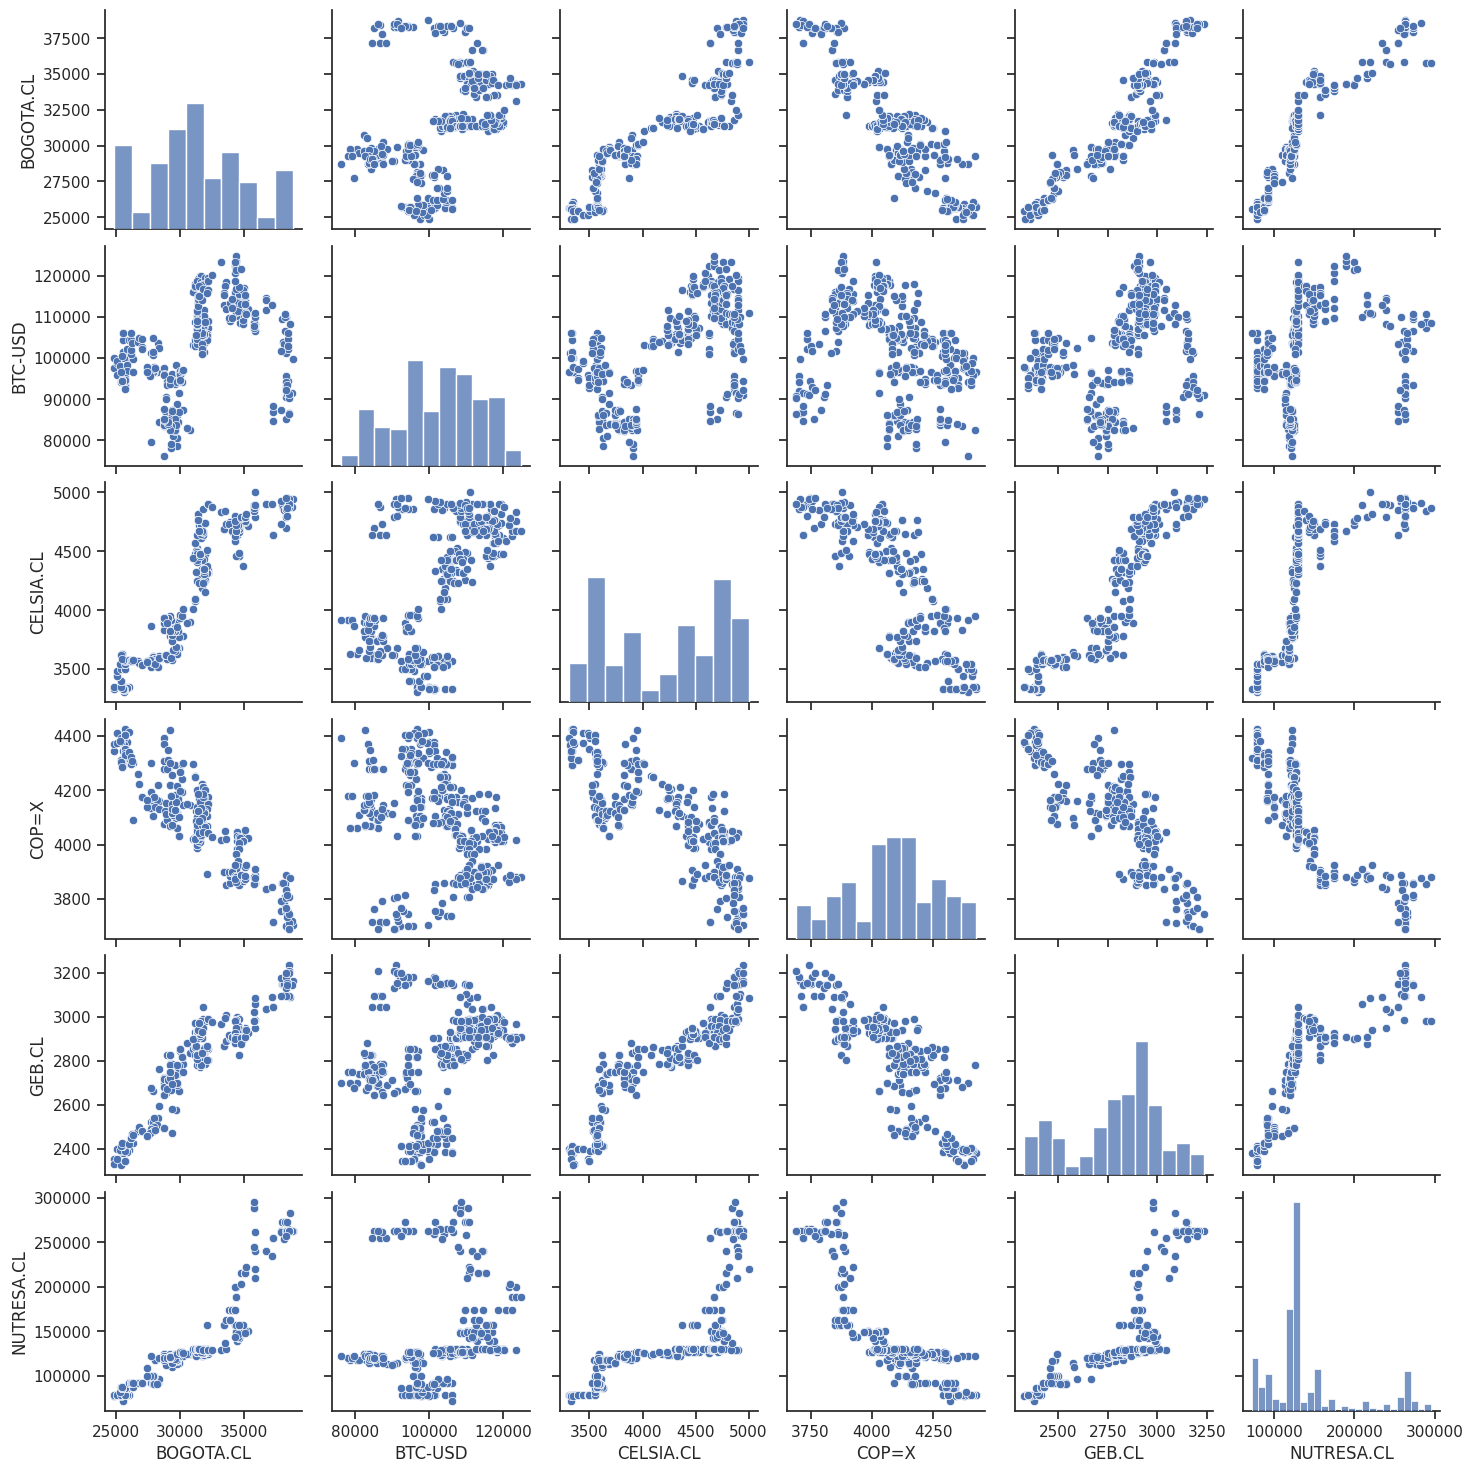

In [28]:
##9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

import seaborn as sns
sns.set(style="ticks")

sns.pairplot(data["Close"])


In [33]:
###10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

# Escogemos nuestra variable predictora como :
X=data["Close"]['BOGOTA.CL'].values.reshape(-1,1)

# Escogemos nuestra variable objetivo  BTC-USD:
y=data["Close"]['BTC-USD'].values.reshape(-1,1)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#seleccionamos los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)

#entrenamos el modelo
linear  = LinearRegression()
linear.fit(X_train,y_train)

LinearRegression()

In [35]:
y_pred = linear.predict(X_test)

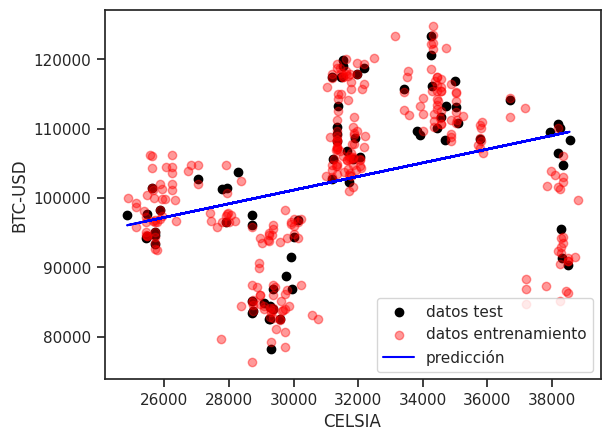

MAE:  8286.931967089367
MSE:  107777395.4158588
RMSE:  10381.58925289663
R2:  0.20076894903820675


In [36]:
plt.scatter(X_test, y_test,  color='black',label=r'datos test')
plt.scatter(X_train, y_train,  color='red',alpha=0.4,label=r'datos entrenamiento')
plt.plot(X_test, y_pred, color='blue',label=r'predicción')
plt.legend(loc='lower right')
plt.xlabel(r'CELSIA')
plt.ylabel(r'BTC-USD')
plt.show()

print('MAE: ', metrics.mean_absolute_error(y_test, y_pred))
print('MSE: ', metrics.mean_squared_error(y_test, y_pred))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2: ', metrics.r2_score(y_test, y_pred))